# Calibração de probabilidades em um modelo de doença cardíaca

**Pergunta:** um modelo com boa discriminação (AUC) também produz probabilidades confiáveis? E o que muda, nas probabilidades e nas classificações, quando aplicamos uma recalibração *post hoc*?

Este projeto treina uma Random Forest na base **Heart Disease (Cleveland) da UCI**, ajusta um recalibrador sigmoide (Platt) em um conjunto separado e compara os dois procedimentos em um teste independente, usando:

- **Qualidade das probabilidades:** Brier score, Brier skill score, log loss;
- **Calibração:** curvas de calibração com IC de Wilson, intercepto de calibração média e inclinação de calibração;
- **Discriminação:** AUC-ROC e average precision;
- **Classificação:** matrizes de confusão e métricas com limiar fixo de 0,50;
- **Incerteza:** bootstrap pareado das diferenças entre os procedimentos.

A amostra tem 303 registros e 13 preditores. O desfecho indica presença de doença cardíaca segundo a classificação diagnóstica da base — **não é a previsão de insuficiência cardíaca nem de um evento futuro**. Variáveis de exames fazem parte deste cenário diagnóstico.

**Fluxo:** dados → divisão → pré-processamento → treinamento → probabilidades originais → ajuste do recalibrador → teste independente → interpretação.

## 1 Ambiente

Requer Python 3.10 ou posterior e scikit-learn 1.6 ou posterior (uso de `FrozenEstimator`). As dependências estão em `requirements.txt`; a célula abaixo instala diretamente no kernel, se necessário.

O scikit-learn implementa o modelo e o calibrador; pandas organiza as tabelas; matplotlib gera os gráficos; scipy é usado nos diagnósticos de intercepto e inclinação.

In [1]:
# %pip install "scikit-learn>=1.6,<2" pandas numpy matplotlib scipy

In [2]:
import io
import hashlib
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score, average_precision_score
from scipy.special import expit
from scipy.optimize import minimize, brentq

SEED = 42
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
pd.set_option('display.max_columns', 20)
print('Python:', platform.python_version())
print('scikit-learn:', sklearn.__version__)

Python: 3.14.0
scikit-learn: 1.7.2


## 2 Fonte e carregamento dos dados

Fonte: [Heart Disease — UCI](https://archive.ics.uci.edu/dataset/45/heart+disease). DOI: [10.24432/C52P4X](https://doi.org/10.24432/C52P4X). Arquivo `processed.cleveland.data` extraído do [ZIP oficial](https://archive.ics.uci.edu/static/public/45/heart+disease.zip). Licença CC BY 4.0.

Uma cópia do arquivo original está em `data/` para permitir execução offline. O hash SHA-256 garante que os bytes lidos são os mesmos usados nesta análise (não é um certificado publicado pela UCI). Os `?` do arquivo representam valores ausentes.

In [3]:
from pathlib import Path

CAMINHO_DADOS = Path('data') / 'processed.cleveland.data'
SHA256_ESPERADO = 'a74b7efa387bc9d108d7d0115d831fe9b414b29ae7124f331b622b4efa0427c8'
assert hashlib.sha256(CAMINHO_DADOS.read_bytes()).hexdigest() == SHA256_ESPERADO
colunas = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
dados = pd.read_csv(CAMINHO_DADOS, names=colunas, na_values='?')
assert dados.shape == (303, 14)
assert dados['num'].notna().all()
display(dados.head())
print('Dimensões:', dados.shape)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Dimensões: (303, 14)


### Dicionário dos preditores

| Campo | Significado | Tratamento |
|---|---|---|
| age | Idade em anos | Numérico |
| sex | Sexo registrado, 0 feminino e 1 masculino | Categórico |
| cp | Tipo de dor torácica, códigos 1 a 4 | Categórico |
| trestbps | Pressão arterial em repouso, mmHg | Numérico |
| chol | Colesterol sérico, mg/dL | Numérico |
| fbs | Glicemia de jejum acima de 120 mg/dL, 0 não e 1 sim | Categórico |
| restecg | Resultado do ECG em repouso, códigos 0 a 2 | Categórico |
| thalach | Frequência cardíaca máxima alcançada | Numérico |
| exang | Angina induzida por exercício, 0 não e 1 sim | Categórico |
| oldpeak | Depressão do segmento ST induzida pelo exercício em relação ao repouso | Numérico |
| slope | Inclinação do segmento ST no pico do exercício, códigos 1 a 3 | Categórico |
| ca | Número de grandes vasos visualizados, 0 a 3 | Numérico de contagem |
| thal | Resultado do exame, 3 normal, 6 defeito fixo e 7 defeito reversível | Categórico |

Esses códigos são específicos desta versão da base. Por exemplo, `thal` tem categorias 3, 6 e 7; não devem ser tratadas como uma escala contínua. A palavra `slope` neste dicionário é uma variável de ECG, diferente da **inclinação de calibração** analisada mais adiante.

## 3 Definição do desfecho e verificação dos dados

O campo `num` contém valores 0 a 4. Definimos **0 = ausência** e **1 = presença**, agrupando os valores originais 1 a 4. `num` nunca entra nos preditores.

`predict_proba(...)[:, 1]` corresponde, portanto, à probabilidade de presença de doença.

In [4]:
X = dados.drop(columns='num')
y = (dados['num'] > 0).astype(int).rename('doenca')
display(pd.DataFrame({'ausentes': X.isna().sum(), 'tipo': X.dtypes.astype(str)}))
display(y.value_counts().sort_index().rename_axis('desfecho').to_frame('n'))
print(f'Frequência da doença na amostra: {y.mean():.1%}')
assert 'num' not in X.columns

,ausentes,tipo
age,0,float64
sex,0,float64
cp,0,float64
trestbps,0,float64
chol,0,float64
fbs,0,float64
restecg,0,float64
thalach,0,float64
exang,0,float64
oldpeak,0,float64


,n
desfecho,
0,164
1,139


Frequência da doença na amostra: 45.9%


## 4 Divisão em treinamento, calibração e teste

Divisão aproximada de 60% / 20% / 20%, estratificada pelo desfecho e com semente fixa para reprodutibilidade.

1. **Treinamento:** aprende imputações, codificação e parâmetros do modelo.
2. **Calibração:** ajusta somente a transformação das saídas do modelo já treinado.
3. **Teste:** compara os dois procedimentos, sem ajustar nenhum deles.

Com apenas 303 registros, as estimativas são incertas; uma divisão única não é uma recomendação geral. Em dados clínicos reais, registros da mesma pessoa devem permanecer no mesmo grupo, e cenários de validação temporal exigem outro esquema de divisão.

In [5]:
X_dev, X_teste, y_dev, y_teste = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
X_treino, X_cal, y_treino, y_cal = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=SEED)
assert set(X_treino.index).isdisjoint(X_cal.index)
assert set(X_treino.index).isdisjoint(X_teste.index)
assert set(X_cal.index).isdisjoint(X_teste.index)
display(pd.DataFrame([
    {'conjunto': nome, 'n': len(yy), 'eventos': int(yy.sum()), 'frequência': yy.mean()}
    for nome, yy in [('Treinamento', y_treino), ('Calibração', y_cal), ('Teste', y_teste)]
]))

,conjunto,n,eventos,frequência
0,Treinamento,181,83,0.458564
1,Calibração,61,28,0.459016
2,Teste,61,28,0.459016


## 5 Pré-processamento e treinamento

Nos campos numéricos, valores ausentes são substituídos pela mediana do treinamento. Nos categóricos, pela categoria mais frequente do treinamento, seguida de one-hot encoding. A `Pipeline` garante que essas operações sejam aprendidas somente no treinamento — ajustar o pré-processamento com toda a base vazaria informação do teste para o desenvolvimento.

O modelo é uma Random Forest com hiperparâmetros definidos antes da avaliação. Não há busca de hiperparâmetros nem seleção de variáveis; quando necessárias, essas etapas também devem ficar dentro do desenvolvimento.

In [6]:
numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categoricas = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
preparo = ColumnTransformer([
    ('numericas', SimpleImputer(strategy='median'), numericas),
    ('categoricas', Pipeline([
        ('imputar', SimpleImputer(strategy='most_frequent')),
        ('codificar', OneHotEncoder(handle_unknown='ignore'))
    ]), categoricas)
])
modelo = Pipeline([
    ('preparo', preparo),
    ('classificador', RandomForestClassifier(
        n_estimators=300, min_samples_leaf=3, random_state=SEED, n_jobs=1))
])
modelo.fit(X_treino, y_treino)
assert list(modelo.classes_) == [0, 1]
print('Modelo treinado. Nenhum dado de calibração ou teste entrou neste ajuste.')

Modelo treinado. Nenhum dado de calibração ou teste entrou neste ajuste.


## 6 Ajuste do recalibrador

`FrozenEstimator` mantém a pipeline treinada fixa, incluindo o pré-processamento. O método `sigmoid` aprende uma transformação de formato sigmoide usando somente o conjunto de calibração.

Em termos gerais: **saída do modelo → transformação aprendida → nova probabilidade**. Quando o estimador fornece `decision_function`, o scikit-learn a utiliza; nesta Random Forest, utiliza as probabilidades. O método sigmoide do scikit-learn não equivale a uma regressão logística sobre o logit da probabilidade.

Apenas esse método, definido a priori, é avaliado. A regressão isotônica é mais flexível e pode sobreajustar com poucos dados; comparar métodos exigiria validação dentro do desenvolvimento, antes do teste final.

Construir uma curva de calibração apenas *avalia*; `calibrado.fit(X_cal, y_cal)` é o passo que *aprende* a correção.

In [7]:
calibrado = CalibratedClassifierCV(
    estimator=FrozenEstimator(modelo), method='sigmoid')
calibrado.fit(X_cal, y_cal)
print('Recalibrador ajustado somente nos dados de calibração.')

Recalibrador ajustado somente nos dados de calibração.


## 7 Aplicação dos dois procedimentos ao teste

Os mesmos registros de teste receberão duas probabilidades: uma do modelo original e outra do modelo com recalibrador. O desfecho do teste é usado apenas nas avaliações a seguir.

Uma previsão maior ou menor para um paciente isolado não demonstra melhora de calibração. A concordância entre probabilidades e desfechos precisa ser avaliada em grupos.

In [8]:
p_original = modelo.predict_proba(X_teste)[:, 1]
p_calibrada = calibrado.predict_proba(X_teste)[:, 1]
assert np.isfinite(p_original).all() and np.isfinite(p_calibrada).all()
assert ((p_calibrada >= 0) & (p_calibrada <= 1)).all()
comparacao = pd.DataFrame({
    'desfecho_observado': y_teste.to_numpy(),
    'probabilidade_original': p_original,
    'probabilidade_calibrada': p_calibrada
}, index=X_teste.index)
display(comparacao.head(10).round(4))

,desfecho_observado,probabilidade_original,probabilidade_calibrada
219,0,0.4293,0.3546
271,0,0.6454,0.6895
89,0,0.0503,0.0452
101,0,0.1439,0.0799
67,0,0.4592,0.3998
244,0,0.1726,0.0946
185,0,0.2638,0.1585
233,0,0.3586,0.2580
168,1,0.6360,0.6764
197,0,0.2926,0.1849


## 8 Brier score passo a passo

Para cada registro calculamos `(probabilidade − desfecho)²`; depois tiramos a média. Neste problema binário, o Brier vai de 0 a 1 e valores menores são melhores.

Exemplo: previsão 0,20 e desfecho 0 produzem erro 0,04; previsão 0,20 e desfecho 1 produzem erro 0,64.

**O Brier avalia a qualidade global das probabilidades.** Ele reflete calibração, resolução e frequência do evento; uma redução isolada não prova melhora de calibração em toda a faixa. Não existe um corte universal para um Brier bom.

In [9]:
conta_brier = comparacao.copy()
conta_brier['erro_quadratico_original'] = (p_original - y_teste.to_numpy()) ** 2
conta_brier['erro_quadratico_calibrado'] = (p_calibrada - y_teste.to_numpy()) ** 2
display(conta_brier.head(8).round(4))
brier_manual = conta_brier['erro_quadratico_original'].mean()
print(f'Brier original calculado manualmente: {brier_manual:.6f}')
assert np.isclose(brier_manual, brier_score_loss(y_teste, p_original))

,desfecho_observado,probabilidade_original,probabilidade_calibrada,erro_quadratico_original,erro_quadratico_calibrado
219,0,0.4293,0.3546,0.1843,0.1257
271,0,0.6454,0.6895,0.4165,0.4754
89,0,0.0503,0.0452,0.0025,0.0020
101,0,0.1439,0.0799,0.0207,0.0064
67,0,0.4592,0.3998,0.2108,0.1599
244,0,0.1726,0.0946,0.0298,0.0089
185,0,0.2638,0.1585,0.0696,0.0251
233,0,0.3586,0.2580,0.1286,0.0666


Brier original calculado manualmente: 0.109943


## 9 Métricas e referência simples

- **Brier e log loss:** menores são melhores. A log loss penaliza fortemente previsões erradas e muito confiantes.
- **AUC-ROC:** discriminação; maior é melhor. Não mede concordância das probabilidades.
- **Average precision:** resumo baseado na curva precisão-revocação, relevante para eventos raros. Não é a área trapezoidal da curva PR.
- **Média prevista e frequência observada:** comparação inicial da calibração média; não mostra toda a curva.
- **Brier skill score:** `1 − Brier / Brier_referência`. Positivo indica desempenho superior à referência escolhida; negativo, inferior.

A referência prevê para todos a frequência da doença no **treinamento**. Ela não aprende nada do teste.

In [10]:
p_referencia = np.full(len(y_teste), y_treino.mean())
brier_ref = brier_score_loss(y_teste, p_referencia)
def metricas(nome, p):
    brier = brier_score_loss(y_teste, p)
    return {'procedimento': nome, 'Brier': brier,
            'Log loss': log_loss(y_teste, p, labels=[0, 1]),
            'AUC ROC': roc_auc_score(y_teste, p),
            'Average precision': average_precision_score(y_teste, p),
            'Média prevista': np.mean(p), 'Frequência observada': y_teste.mean(),
            'Brier skill score': 1 - brier / brier_ref}
resultados = pd.DataFrame([
    metricas('Referência constante', p_referencia),
    metricas('Original', p_original),
    metricas('Calibrado sigmoide', p_calibrada)
]).set_index('procedimento')
display(resultados.round(4))
delta = resultados.loc['Calibrado sigmoide', 'Brier'] - resultados.loc['Original', 'Brier']
print(f'Diferença de Brier (calibrado − original): {delta:+.4f}')
print('Neste teste, o Brier ' + ('diminuiu.' if delta < 0 else 'aumentou ou permaneceu igual.'))

,Brier,Log loss,AUC ROC,Average precision,Média prevista,Frequência observada,Brier skill score
procedimento,,,,,,,
Referência constante,0.2483,0.6898,0.5000,0.4590,0.4586,0.459,0.0000
Original,0.1099,0.3676,0.9416,0.9142,0.4947,0.459,0.5573
Calibrado sigmoide,0.0979,0.3301,0.9416,0.9142,0.4829,0.459,0.6057


Diferença de Brier (calibrado − original): -0.0120
Neste teste, o Brier diminuiu.


## 10 Curvas de calibração

As previsões são separadas em até cinco grupos por quantis. Em cada grupo calculamos a média prevista (eixo x) e a proporção de eventos (eixo y). Empates podem reduzir a quantidade de grupos.

O intervalo de Wilson expressa a incerteza da proporção observada **dentro de cada grupo**; não é uma banda de confiança da curva inteira nem incorpora a incerteza do treinamento. Os grupos podem conter pessoas diferentes nos dois procedimentos, pois são formados separadamente.

Leitura: pontos acima da diagonal indicam subestimação; abaixo, superestimação. Cinco pontos são um resumo, não uma prova de calibração perfeita entre eles.

In [11]:
def tabela_calibracao(y_real, p, n_grupos=5):
    t = pd.DataFrame({'y': np.asarray(y_real), 'p': np.asarray(p)})
    t['grupo'] = pd.qcut(t['p'], q=n_grupos, duplicates='drop')
    out = t.groupby('grupo', observed=True).agg(
        n=('y', 'size'), eventos=('y', 'sum'),
        prevista=('p', 'mean'), observada=('y', 'mean')).reset_index()
    z = 1.96
    n, f = out['n'].to_numpy(), out['observada'].to_numpy()
    centro = (f + z*z/(2*n)) / (1 + z*z/n)
    metade = z*np.sqrt(f*(1-f)/n + z*z/(4*n*n)) / (1 + z*z/n)
    out['IC95 inferior'] = centro - metade
    out['IC95 superior'] = centro + metade
    return out

tab_original = tabela_calibracao(y_teste, p_original)
tab_calibrada = tabela_calibracao(y_teste, p_calibrada)
print('Original')
display(tab_original.round(3))
print('Calibrado')
display(tab_calibrada.round(3))

Original


,grupo,n,eventos,prevista,observada,IC95 inferior,IC95 superior
0,"(0.0183, 0.162]",13,0,0.094,0.000,0.000,0.228
1,"(0.162, 0.429]",12,1,0.274,0.083,0.015,0.354
2,"(0.429, 0.645]",12,6,0.539,0.500,0.254,0.746
3,"(0.645, 0.783]",12,10,0.717,0.833,0.552,0.953
4,"(0.783, 0.977]",12,11,0.882,0.917,0.646,0.985


Calibrado


,grupo,n,eventos,prevista,observada,IC95 inferior,IC95 superior
0,"(0.0363, 0.0887]",13,0,0.061,0.000,0.000,0.228
1,"(0.0887, 0.355]",12,1,0.181,0.083,0.015,0.354
2,"(0.355, 0.689]",12,6,0.526,0.500,0.254,0.746
3,"(0.689, 0.844]",12,10,0.775,0.833,0.552,0.953
4,"(0.844, 0.95]",12,11,0.907,0.917,0.646,0.985


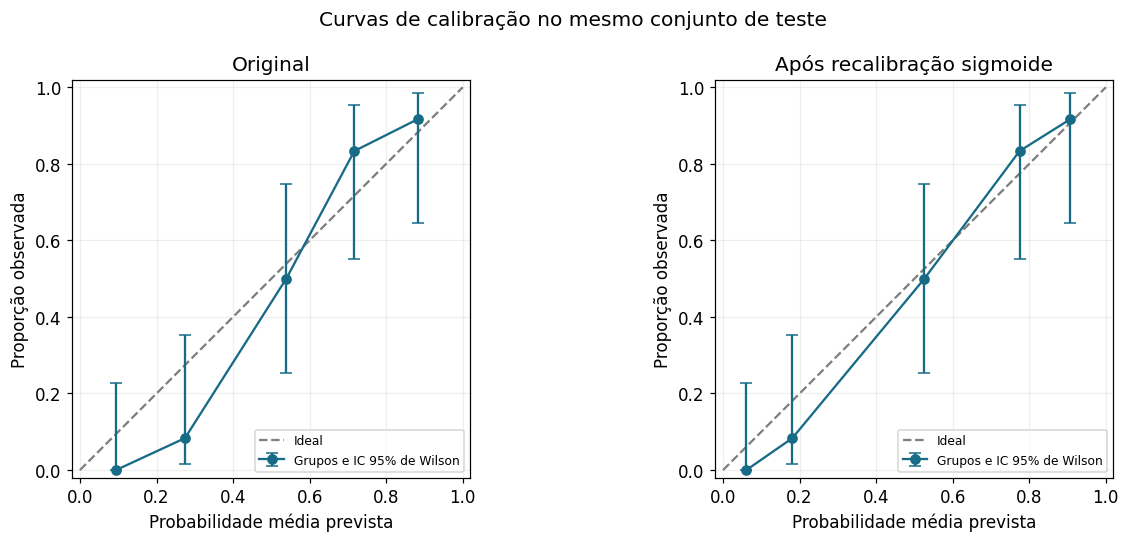

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, titulo, tabela in zip(axes, ['Original', 'Após recalibração sigmoide'],
                              [tab_original, tab_calibrada]):
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Ideal')
    ax.errorbar(tabela['prevista'], tabela['observada'],
                yerr=np.vstack([tabela['observada'] - tabela['IC95 inferior'],
                                tabela['IC95 superior'] - tabela['observada']]),
                fmt='o-', capsize=4, color='#176b87', label='Grupos e IC 95% de Wilson')
    ax.set(xlim=(-0.02, 1.02), ylim=(-0.02, 1.02),
           xlabel='Probabilidade média prevista', ylabel='Proporção observada', title=titulo)
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc='lower right')
fig.suptitle('Curvas de calibração no mesmo conjunto de teste')
fig.tight_layout()
plt.show()

### Distribuição das previsões

Uma região sem previsões tem pouca ou nenhuma informação para avaliar calibração. O histograma ajuda a saber onde o modelo concentrou suas probabilidades. Não se deve concluir que a curva é adequada em regiões sem pacientes.

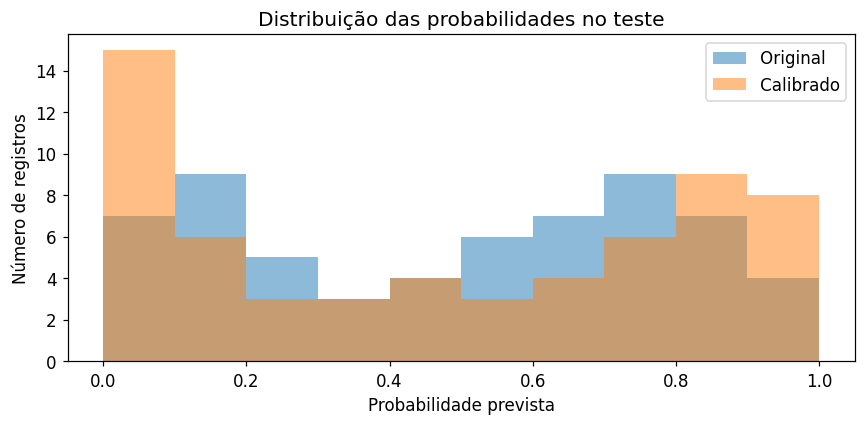

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(p_original, bins=np.linspace(0, 1, 11), alpha=0.5, label='Original')
ax.hist(p_calibrada, bins=np.linspace(0, 1, 11), alpha=0.5, label='Calibrado')
ax.set(xlabel='Probabilidade prevista', ylabel='Número de registros',
       title='Distribuição das probabilidades no teste')
ax.legend()
fig.tight_layout()
plt.show()

## 11 Transformação aprendida pelo recalibrador

Cada ponto abaixo representa um registro do teste. O eixo x mostra a probabilidade original e o eixo y a probabilidade após a transformação. **Este gráfico não é uma curva de calibração**, pois os dois eixos são previsões; ele mostra a correção aplicada.

O código também acessa o calibrador ajustado para inspecionar seus parâmetros. Essa inspeção usa um atributo interno; o uso em produção deve continuar sendo `calibrado.predict_proba`.

Uma transformação monotônica pode preservar a AUC ao mudar as probabilidades. Empates numéricos, outros métodos e ensembles podem modificar esse resultado.

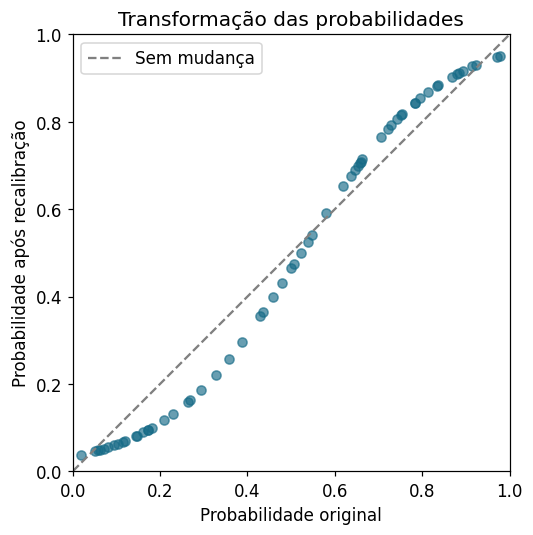

Parâmetros da transformação sigmoide: A=-6.4651; B=3.3748
Neste modelo: p_calibrada = 1 / (1 + exp(A * p_original + B))


In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], '--', color='gray', label='Sem mudança')
ax.scatter(p_original, p_calibrada, alpha=0.65, color='#176b87')
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='Probabilidade original',
       ylabel='Probabilidade após recalibração', title='Transformação das probabilidades')
ax.set_aspect('equal')
ax.legend()
fig.tight_layout()
plt.show()
sigmoide = calibrado.calibrated_classifiers_[0].calibrators[0]
print('Parâmetros da transformação sigmoide:',
      f'A={sigmoide.a_:.4f}; B={sigmoide.b_:.4f}')
print('Neste modelo: p_calibrada = 1 / (1 + exp(A * p_original + B))')

## 12 Intercepto e inclinação de calibração

Esta seção **estima medidas no teste**, sem alterar o modelo utilizado para prever.

O intercepto de calibração média é estimado em `logit(P(Y=1)) = a + logit(p)`, com inclinação fixada em 1. Alvo: `a = 0`; positivo sugere subestimação e negativo superestimação.

A inclinação é estimada em uma segunda regressão: `logit(P(Y=1)) = α + β × logit(p)`, com ambos os parâmetros livres. Alvo: `β = 1`; abaixo de 1 sugere probabilidades demasiado extremas, acima de 1 demasiado moderadas. O α desta segunda regressão não deve ser confundido com o intercepto de calibração média calculado separadamente.

Com poucos eventos, as medidas podem ser instáveis. Intercepto próximo de 0 e inclinação próxima de 1 não garantem concordância em todas as faixas. Para evitar logaritmos indefinidos, os valores usados no diagnóstico são limitados ao intervalo [0,000001; 0,999999].

In [15]:
def diagnosticos_calibracao(y_real, p):
    yy = np.asarray(y_real, dtype=float)
    pp = np.clip(p, 1e-6, 1-1e-6)
    lp = np.log(pp / (1-pp))
    a_media = brentq(lambda a: np.sum(expit(a + lp) - yy), -50, 50)
    design = np.column_stack([np.ones(len(yy)), lp])
    def objetivo(theta):
        eta = design @ theta
        return np.sum(np.logaddexp(0, eta) - yy * eta)
    def gradiente(theta):
        return design.T @ (expit(design @ theta) - yy)
    fit = minimize(objetivo, [0.0, 1.0], jac=gradiente, method='BFGS')
    convergiu = fit.success or np.linalg.norm(gradiente(fit.x)) < 1e-5
    return {'intercepto média': a_media,
            'inclinação': fit.x[1] if convergiu else np.nan,
            'convergência': convergiu}
display(pd.DataFrame({
    'Original': diagnosticos_calibracao(y_teste, p_original),
    'Calibrado': diagnosticos_calibracao(y_teste, p_calibrada)
}).T)

,intercepto média,inclinação,convergência
Original,-0.218546,2.106414,True
Calibrado,-0.173425,1.575374,True


## 13 Incerteza da diferença de Brier

Bootstrap pareado do teste: sorteamos os mesmos índices para os dois procedimentos. A diferença é `Brier calibrado − Brier original`; negativo favorece a versão calibrada.

O intervalo percentil abaixo considera a variabilidade do teste **condicionada ao modelo e ao calibrador já ajustados**. Ele não inclui a incerteza de toda a construção do modelo. Com vários registros por pessoa, a reamostragem deveria ser feita por paciente.

Se o intervalo incluir zero, os dados são compatíveis com diferenças em ambas as direções. Isso não demonstra equivalência e não autoriza escolher outro método usando repetidamente o mesmo teste.

In [16]:
rng = np.random.default_rng(SEED)
yy = y_teste.to_numpy()
erro_original = (p_original - yy) ** 2
erro_calibrado = (p_calibrada - yy) ** 2
dif_individual = erro_calibrado - erro_original
indices_boot = rng.integers(0, len(yy), size=(2000, len(yy)))
dif_boot = dif_individual[indices_boot].mean(axis=1)
lim_inf, lim_sup = np.quantile(dif_boot, [0.025, 0.975])
print(f'Diferença observada: {dif_individual.mean():+.4f}')
print(f'IC 95% bootstrap percentil: [{lim_inf:+.4f}, {lim_sup:+.4f}]')
print('O intervalo inclui zero?', bool(lim_inf <= 0 <= lim_sup))

Diferença observada: -0.0120
IC 95% bootstrap percentil: [-0.0199, -0.0029]
O intervalo inclui zero? False


## 14 De probabilidades a classificações

As métricas de classificação mudaram? Para responder, usamos **o mesmo limiar de 0,50, definido previamente, para ambos os procedimentos**:

`classe prevista = 1 se probabilidade ≥ 0,50; caso contrário, 0`.

O limiar é uma escolha de referência, não uma recomendação clínica. Probabilidades podem melhorar sem que nenhuma classificação mude; se uma previsão atravessa o limiar, o efeito no acerto depende do desfecho real.

Brier e log loss usam as probabilidades; a matriz de confusão usa as classes após o limiar. Mantemos os mesmos pacientes e o mesmo limiar para comparar.

In [17]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
    balanced_accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, classification_report,
    roc_curve, precision_recall_curve
)

LIMIAR = 0.50  # Definido antes da comparação; não otimizar no teste.
classe_original = (p_original >= LIMIAR).astype(int)
classe_calibrada = (p_calibrada >= LIMIAR).astype(int)
print(f'Mesmo limiar nos dois procedimentos: {LIMIAR:.0%}')

Mesmo limiar nos dois procedimentos: 50%


## 15 Matrizes de confusão

As **linhas representam o desfecho observado** e as **colunas a classificação prevista**. Classe 0 = ausência; classe 1 = presença de doença.

| | Previsto sem doença | Previsto com doença |
|---|---|---|
| Observado sem doença | Verdadeiro negativo VN | Falso positivo FP |
| Observado com doença | Falso negativo FN | Verdadeiro positivo VP |

Os acertos estão na diagonal. Um FP classifica como positiva uma pessoa sem doença; um FN classifica como negativa uma pessoa com doença.

Os gráficos seguintes mostram contagens e, depois, percentuais normalizados por linha. Na linha das pessoas com doença, VP/(VP+FN) é a sensibilidade; na linha sem doença, VN/(VN+FP) é a especificidade. Uma célula zerada não garante que esse erro nunca acontecerá em outros dados.

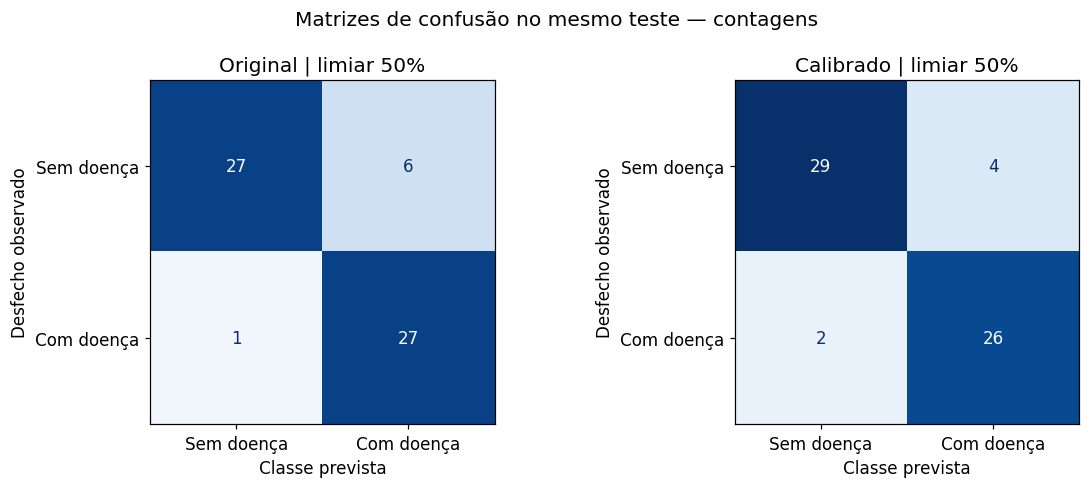

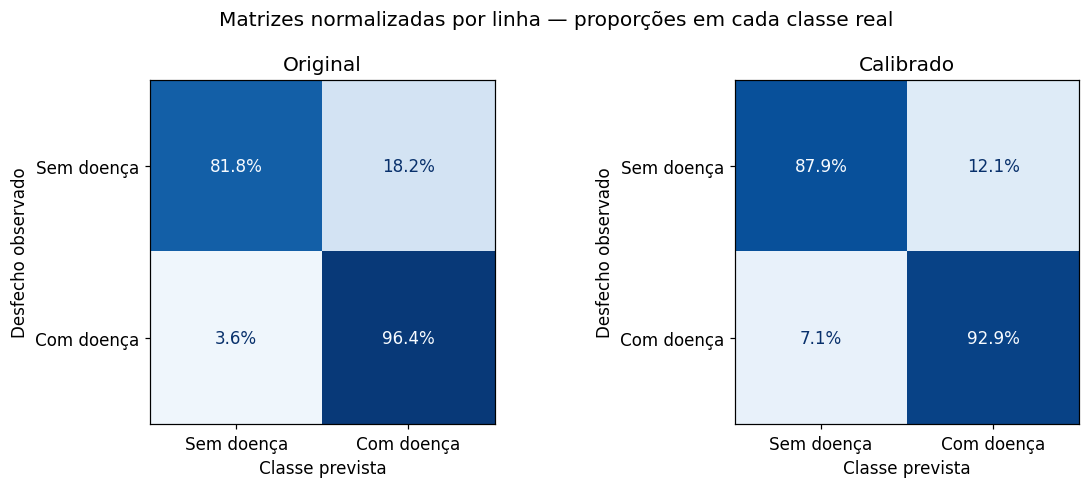

In [18]:
matriz_original = confusion_matrix(y_teste, classe_original, labels=[0, 1])
matriz_calibrada = confusion_matrix(y_teste, classe_calibrada, labels=[0, 1])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
max_contagem = max(matriz_original.max(), matriz_calibrada.max())
for ax, nome, matriz in zip(axes, ['Original', 'Calibrado'],
                            [matriz_original, matriz_calibrada]):
    disp = ConfusionMatrixDisplay(matriz, display_labels=['Sem doença', 'Com doença'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d',
              im_kw={'vmin': 0, 'vmax': max_contagem})
    ax.set_title(f'{nome} | limiar {LIMIAR:.0%}')
    ax.set_xlabel('Classe prevista')
    ax.set_ylabel('Desfecho observado')
fig.suptitle('Matrizes de confusão no mesmo teste — contagens')
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, nome, pred in zip(axes, ['Original', 'Calibrado'],
                         [classe_original, classe_calibrada]):
    matriz = confusion_matrix(y_teste, pred, labels=[0, 1], normalize='true')
    ConfusionMatrixDisplay(matriz, display_labels=['Sem doença', 'Com doença']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='.1%',
        im_kw={'vmin': 0, 'vmax': 1})
    ax.set_title(nome)
    ax.set_xlabel('Classe prevista')
    ax.set_ylabel('Desfecho observado')
fig.suptitle('Matrizes normalizadas por linha — proporções em cada classe real')
fig.tight_layout()
plt.show()

## 16 Métricas de classificação

| Medida | Fórmula | Leitura |
|---|---|---|
| Acurácia | (VP+VN)/n | Fração total de acertos |
| Sensibilidade ou recall | VP/(VP+FN) | Fração dos doentes identificada |
| Especificidade | VN/(VN+FP) | Fração dos não doentes identificada |
| VPP ou precisão | VP/(VP+FP) | Fração de doentes entre os classificados positivos |
| VPN | VN/(VN+FN) | Fração de não doentes entre os classificados negativos |
| F1 | 2VP/(2VP+FP+FN) | Combina VPP e sensibilidade |
| Acurácia balanceada | (sensibilidade+especificidade)/2 | Dá o mesmo peso às duas classes |

O coeficiente de Matthews (MCC) resume as quatro células: 1 corresponde a classificação perfeita, 0 indica ausência de associação nessa medida e −1 corresponde a inversão completa das classes. Acurácia alta pode esconder baixa sensibilidade quando o evento é raro. VPP e VPN dependem da frequência da doença na população.

Denominadores iguais a zero produzem `NaN` na função abaixo. Isso significa métrica indefinida; não é desempenho de 0%. Neste teste há as duas classes.

In [19]:
def dividir_seguro(a, b):
    return a / b if b != 0 else np.nan

def metricas_classificacao(y_real, pred):
    vn, fp, fn, vp = confusion_matrix(y_real, pred, labels=[0, 1]).ravel()
    sens = dividir_seguro(vp, vp + fn)
    espec = dividir_seguro(vn, vn + fp)
    return {
        'Limiar': LIMIAR,
        'VN': int(vn), 'FP': int(fp), 'FN': int(fn), 'VP': int(vp),
        'Acurácia': dividir_seguro(vp + vn, vn + fp + fn + vp),
        'Sensibilidade': sens,
        'Especificidade': espec,
        'VPP precisão': dividir_seguro(vp, vp + fp),
        'VPN': dividir_seguro(vn, vn + fn),
        'F1': dividir_seguro(2*vp, 2*vp + fp + fn),
        'Acurácia balanceada': (sens + espec) / 2,
        'MCC': matthews_corrcoef(y_real, pred)
    }

tabela_classes = pd.DataFrame({
    'Original': metricas_classificacao(y_teste, classe_original),
    'Calibrado sigmoide': metricas_classificacao(y_teste, classe_calibrada)
}).T
display(tabela_classes.round(4))

# Conferir as contas com as funções oficiais do sklearn.
for nome, pred in [('Original', classe_original), ('Calibrado sigmoide', classe_calibrada)]:
    linha = tabela_classes.loc[nome]
    assert np.isclose(linha['Acurácia'], accuracy_score(y_teste, pred))
    assert np.isclose(linha['Sensibilidade'], recall_score(y_teste, pred))
    assert np.isclose(linha['VPP precisão'], precision_score(y_teste, pred))
    assert np.isclose(linha['F1'], f1_score(y_teste, pred))
    assert np.isclose(linha['Acurácia balanceada'], balanced_accuracy_score(y_teste, pred))

,Limiar,VN,FP,FN,VP,Acurácia,Sensibilidade,Especificidade,VPP precisão,VPN,F1,Acurácia balanceada,MCC
Original,0.5,27.0,6.0,1.0,27.0,0.8852,0.9643,0.8182,0.8182,0.9643,0.8852,0.8912,0.7825
Calibrado sigmoide,0.5,29.0,4.0,2.0,26.0,0.9016,0.9286,0.8788,0.8667,0.9355,0.8966,0.9037,0.8048


### Relatório por classe

O relatório abaixo também calcula precisão, recall e F1 tomando cada classe como alvo. `Support` é o número de registros daquela classe real. O recall da classe **sem doença** corresponde à especificidade; o recall da classe **com doença** corresponde à sensibilidade. As médias macro e ponderada têm significados diferentes; não substituem a leitura das duas classes.

In [20]:
for nome, pred in [('Original', classe_original), ('Calibrado', classe_calibrada)]:
    print('\n' + nome)
    print(classification_report(
        y_teste, pred, labels=[0, 1],
        target_names=['Sem doença', 'Com doença'], digits=4, zero_division=np.nan))


Original
              precision    recall  f1-score   support

  Sem doença     0.9643    0.8182    0.8852        33
  Com doença     0.8182    0.9643    0.8852        28

    accuracy                         0.8852        61
   macro avg     0.8912    0.8912    0.8852        61
weighted avg     0.8972    0.8852    0.8852        61


Calibrado
              precision    recall  f1-score   support

  Sem doença     0.9355    0.8788    0.9062        33
  Com doença     0.8667    0.9286    0.8966        28

    accuracy                         0.9016        61
   macro avg     0.9011    0.9037    0.9014        61
weighted avg     0.9039    0.9016    0.9018        61



## 17 Tabela consolidada: antes e depois

A tabela completa reúne Brier, BSS, log loss, AUC, average precision, calibração média e métricas da classificação. A referência do BSS permanece a previsão constante da frequência observada no treinamento, avaliada no mesmo teste.

Na tabela de diferenças, **depois − antes**: valores negativos favorecem o calibrado para Brier e log loss; positivos favorecem o calibrado para AUC, AP, BSS e métricas de acerto. Para intercepto e inclinação, observe a proximidade dos alvos 0 e 1, respectivamente, sem usar apenas o sinal da diferença.

In [21]:
tabela_completa = resultados.loc[['Original', 'Calibrado sigmoide']].join(tabela_classes)
diag_tabela = pd.DataFrame({
    nome: diagnosticos_calibracao(y_teste, p)
    for nome, p in [('Original', p_original), ('Calibrado sigmoide', p_calibrada)]
}).T.rename(columns={'intercepto média': 'Intercepto calibração média',
                    'inclinação': 'Inclinação calibração'})
tabela_completa = tabela_completa.join(diag_tabela)
display(tabela_completa.T)

medidas = ['Brier', 'Brier skill score', 'Log loss', 'AUC ROC', 'Average precision',
           'Acurácia', 'Sensibilidade', 'Especificidade', 'VPP precisão', 'VPN',
           'F1', 'Acurácia balanceada', 'MCC']
tabela_diferencas = tabela_completa[medidas].T
tabela_diferencas['Depois − antes'] = (
    tabela_diferencas['Calibrado sigmoide'] - tabela_diferencas['Original'])
display(tabela_diferencas.round(4))

procedimento,Original,Calibrado sigmoide
Brier,0.109943,0.097921
Log loss,0.36763,0.330129
AUC ROC,0.941558,0.941558
Average precision,0.91423,0.91423
Média prevista,0.494704,0.482893
Frequência observada,0.459016,0.459016
Brier skill score,0.557254,0.605667
Limiar,0.5,0.5
VN,27.0,29.0
FP,6.0,4.0


procedimento,Original,Calibrado sigmoide,Depois − antes
Brier,0.1099,0.0979,-0.0120
Brier skill score,0.5573,0.6057,0.0484
Log loss,0.3676,0.3301,-0.0375
AUC ROC,0.9416,0.9416,0.0000
Average precision,0.9142,0.9142,0.0000
Acurácia,0.8852,0.9016,0.0164
Sensibilidade,0.9643,0.9286,-0.0357
Especificidade,0.8182,0.8788,0.0606
VPP precisão,0.8182,0.8667,0.0485
VPN,0.9643,0.9355,-0.0288


## 18 Classificações alteradas

As probabilidades de um paciente podem mudar sem atravessar o limiar. Aqui identificamos somente as mudanças de classe e verificar se elas corrigiram um erro ou criaram um novo erro.

O índice da tabela corresponde à linha da base, não a um identificador clínico real. Os desfechos entram apenas nesta avaliação; na aplicação a uma pessoa nova eles são desconhecidos.

In [22]:
mudancas = comparacao.copy()
mudancas['classe_original'] = classe_original
mudancas['classe_calibrada'] = classe_calibrada
mudancas['acertou_original'] = classe_original == y_teste.to_numpy()
mudancas['acertou_calibrado'] = classe_calibrada == y_teste.to_numpy()
mudancas['mudou_classe'] = classe_original != classe_calibrada
mudancas['efeito'] = np.select([
    ~mudancas['acertou_original'] & mudancas['acertou_calibrado'],
    mudancas['acertou_original'] & ~mudancas['acertou_calibrado']
], ['Erro corrigido', 'Novo erro'], default='Acerto ou erro mantido')
display(mudancas.loc[mudancas['mudou_classe']].round(4))
print('Classificações alteradas:', int(mudancas['mudou_classe'].sum()))
print('Erros corrigidos:', int((mudancas['efeito'] == 'Erro corrigido').sum()))
print('Novos erros:', int((mudancas['efeito'] == 'Novo erro').sum()))
print('Mudança na acurácia:',
      f"{tabela_classes.loc['Calibrado sigmoide', 'Acurácia'] - tabela_classes.loc['Original', 'Acurácia']:+.4f}")

,desfecho_observado,probabilidade_original,probabilidade_calibrada,classe_original,classe_calibrada,acertou_original,acertou_calibrado,mudou_classe,efeito
196,0,0.5215,0.4992,1,0,False,True,True,Erro corrigido
186,0,0.5005,0.4653,1,0,False,True,True,Erro corrigido
172,1,0.5066,0.4751,1,0,True,False,True,Novo erro


Classificações alteradas: 3
Erros corrigidos: 2
Novos erros: 1
Mudança na acurácia: +0.0164


## 19 Curvas ROC e precisão-revocação

Essas curvas usam vários limiares para resumir discriminação. Não são curvas de calibração. Na ROC, o eixo x é a taxa de falsos positivos e o eixo y é a sensibilidade. Na curva PR, x é a sensibilidade e y é o VPP.

Os dois traçados podem ficar sobrepostos porque a transformação sigmoide preserva a ordenação neste exemplo. Assim, é possível mudar Brier e log loss mantendo a AUC e a average precision. A referência horizontal na PR é a frequência da classe positiva no teste; o valor da AP é calculado pela função `average_precision_score`, não por integração trapezoidal.

Nenhum limiar ótimo é escolhido nestes gráficos: a seleção de um limiar deve ocorrer no desenvolvimento, orientada pela aplicação clínica.

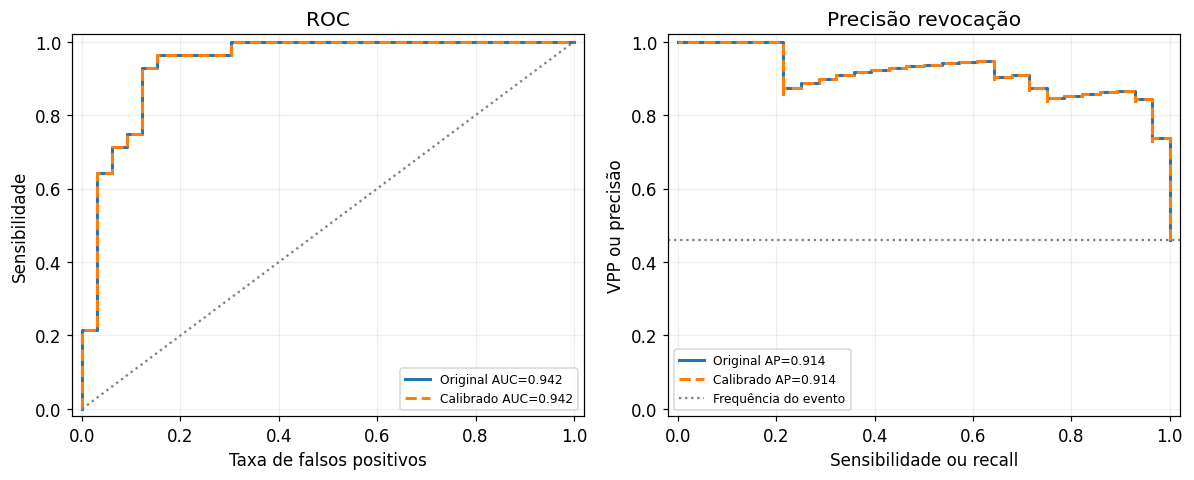

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for nome, p, estilo in [('Original', p_original, '-'), ('Calibrado', p_calibrada, '--')]:
    fpr, tpr, _ = roc_curve(y_teste, p)
    precisao, revocacao, _ = precision_recall_curve(y_teste, p)
    axes[0].plot(fpr, tpr, estilo, linewidth=2,
                 label=f'{nome} AUC={roc_auc_score(y_teste, p):.3f}')
    axes[1].step(revocacao, precisao, where='post', linestyle=estilo,
                 linewidth=2, label=f'{nome} AP={average_precision_score(y_teste, p):.3f}')
axes[0].plot([0, 1], [0, 1], ':', color='gray')
axes[0].set(xlabel='Taxa de falsos positivos', ylabel='Sensibilidade', title='ROC')
axes[1].axhline(y_teste.mean(), linestyle=':', color='gray', label='Frequência do evento')
axes[1].set(xlabel='Sensibilidade ou recall', ylabel='VPP ou precisão', title='Precisão revocação')
for ax in axes:
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

### Incerteza da diferença de acurácia

Também reamostramos de forma pareada os acertos dos dois procedimentos. Este intervalo considera somente a variabilidade do teste, com modelo e recalibrador fixos. Um intervalo estreito ou até degenerado não estabelece superioridade geral: o teste é pequeno, e a incerteza do desenvolvimento não está incluída.

In [24]:
acerto_original = (classe_original == y_teste.to_numpy()).astype(float)
acerto_calibrado = (classe_calibrada == y_teste.to_numpy()).astype(float)
delta_acerto = acerto_calibrado - acerto_original
boot_acuracia = delta_acerto[indices_boot].mean(axis=1)
li_acc, ls_acc = np.quantile(boot_acuracia, [0.025, 0.975])
print(f'Diferença de acurácia: {100*delta_acerto.mean():+.2f} pontos percentuais')
print(f'IC 95% bootstrap: [{100*li_acc:+.2f}; {100*ls_acc:+.2f}] pontos percentuais')

print('\nResumo desta execução')
print(f"Brier: {resultados.loc['Original', 'Brier']:.4f} → {resultados.loc['Calibrado sigmoide', 'Brier']:.4f}")
print(f"BSS: {resultados.loc['Original', 'Brier skill score']:.4f} → {resultados.loc['Calibrado sigmoide', 'Brier skill score']:.4f}")
print(f"Acurácia: {acerto_original.mean():.1%} → {acerto_calibrado.mean():.1%}")
print('A melhora das probabilidades e a mudança dos acertos são conclusões distintas.')

Diferença de acurácia: +1.64 pontos percentuais
IC 95% bootstrap: [-3.28; +8.20] pontos percentuais

Resumo desta execução
Brier: 0.1099 → 0.0979
BSS: 0.5573 → 0.6057
Acurácia: 88.5% → 90.2%
A melhora das probabilidades e a mudança dos acertos são conclusões distintas.


## 20 Resultados e conclusões

No conjunto de teste (61 registros, 28 eventos):

| Medida | Original | Calibrado (sigmoide) |
|---|---|---|
| Brier | 0,110 | **0,098** |
| Brier skill score | 0,557 | **0,606** |
| Log loss | 0,367 | **0,330** |
| AUC-ROC | 0,942 | 0,942 |
| Intercepto de calibração média | −0,22 | −0,17 |
| Inclinação de calibração | 2,11 | 1,58 |
| Acurácia (limiar 0,50) | 88,5% | 90,2% |

- **As probabilidades melhoraram:** o Brier caiu 0,012 (IC 95% bootstrap pareado: −0,020 a −0,003) e a log loss também diminuiu.
- **A discriminação não mudou:** a transformação sigmoide é monotônica e preserva a ordenação, então AUC e average precision são idênticas.
- **A Random Forest original era moderada demais:** inclinação ≈ 2,1 indica probabilidades comprimidas em direção ao centro; a recalibração aproximou a inclinação de 1, mas não totalmente.
- **As classificações quase não mudaram:** apenas 3 registros atravessaram o limiar — dois erros corrigidos e um novo erro —, trocando um pouco de sensibilidade (96,4% → 92,9%) por especificidade (81,8% → 87,9%). A acurácia subiu 1,6 ponto percentual, mas o IC 95% bootstrap (−3,3 a +8,2 p.p.) inclui zero, e esses registros estão muito próximos do limiar (p ≈ 0,47–0,52), de modo que a diferença é frágil.

**Mensagem central:** melhorar a qualidade das probabilidades e melhorar acertos de classificação são conclusões distintas. Um menor Brier indica melhor desempenho global das probabilidades neste teste, não melhora garantida em todas as faixas de risco.

*Valores obtidos com Python 3.14 e scikit-learn 1.7.2; pequenas variações podem ocorrer em outras versões.*

### Limitações

- Amostra pequena (303 registros; teste com 61), com intervalos amplos.
- Uma única divisão treino/calibração/teste; os intervalos bootstrap são condicionais ao modelo e ao calibrador já ajustados.
- Cenário diagnóstico retrospectivo, sem validação externa ou temporal e sem validade clínica estabelecida.

### Boas práticas para aplicação em dados reais

- Definir o instante da previsão e incluir apenas informações disponíveis naquele instante.
- Separar por paciente, mantendo todos os registros de uma pessoa no mesmo grupo.
- Em validação cruzada aninhada, fazer seleção de variáveis, ajuste do modelo e recalibração apenas com o treinamento de cada fold.
- Qualquer nova recalibração exige ajuste e avaliação independentes: se o teste for usado para ajustar uma transformação, ele passa a fazer parte do desenvolvimento.

### Próximos passos

Decomposição do Brier, curvas de calibração suavizadas, intervalos para intercepto e inclinação, comparação com regressão isotônica via validação cruzada e *decision curve analysis*. ECE depende dos grupos definidos e não substitui a curva; o teste de Hosmer–Lemeshow não deve ser a principal evidência de calibração.

## Referências

1. Janosi A, Steinbrunn W, Pfisterer M, Detrano R. Heart Disease [Dataset]. UCI Machine Learning Repository; 1989. https://doi.org/10.24432/C52P4X.
2. Scikit-learn. Probability calibration. https://scikit-learn.org/stable/modules/calibration.html.
3. Scikit-learn. Metrics and scoring. https://scikit-learn.org/stable/modules/model_evaluation.html.
4. Van Calster B, McLernon DJ, van Smeden M, et al. Calibration: the Achilles heel of predictive analytics. BMC Medicine. 2019;17:230. https://doi.org/10.1186/s12916-019-1466-7.
5. Huang Y, Li W, Macheret F, Gabriel RA, Ohno-Machado L. A tutorial on calibration measurements and calibration models for clinical prediction models. JAMIA. 2020;27(4):621–633. https://doi.org/10.1093/jamia/ocz228.

Os gráficos e tabelas correspondem a um estudo exploratório, sem validade clínica estabelecida.